# Sentiment Analysis

### *Part III - Language Task*
<br>


**Module:** 6CS012 Artificial Intelligence
<br>
**Task:** Text Classification with RNN

**Student**: Pratisha Bista <BR>
**ID:** 2408284

**Group:** L6CG1

# Text Preprocessing, Tokenization, and Sequence Padding

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [ ]:
DATASET_PATH = Path('/content/drive/MyDrive/3. 6CS012: AI & ML Part III/Financial Phrase Dataset')
MODELS_PATH = Path('/content/drive/MyDrive/3. 6CS012: AI & ML Part III/Models')
FIGURES_PATH = Path('/content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures')

try:
    print("Dataset root contents:", os.listdir(DATASET_PATH))
except FileNotFoundError as e:
    print(f"Error: One or more dataset directories not found: {e}")
except Exception as e:
    print(f"An unexpected error occurred while listing directory contents: {e}")

Dataset root contents: ['financial_phrase.csv']


In [ ]:
def save_plot(fig, filename):
    """
    Saves a matplotlib figure to the FIGURES_PATH directory.
    Args:
        fig (matplotlib.figure.Figure): The figure object to save.
        filename (str): The name of the file to save the figure as.
    """
    full_path = os.path.join(FIGURES_PATH, filename)
    try:
        fig.savefig(full_path)
        print(f"Plot saved to: {full_path}")
    except Exception as e:
        print(f"Error saving plot to {full_path}: {e}")

## Exploratory Data Analysis (EDA)

/tmp/ipykernel_4299/2059940744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis', order=df['label'].value_counts().index)


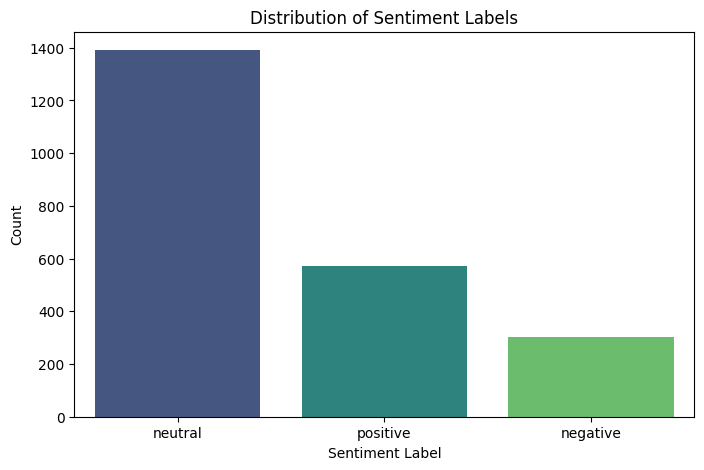

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/sentiment_distribution.png
Sentiment Label Counts:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sentiment Label Percentages:
label
neutral     61.439929
positive    25.176678
negative    13.383392
Name: count, dtype: float64

Classes identified as imbalanced (below 20% threshold):
label
negative    13.383392
Name: count, dtype: float64
This indicates a significant class imbalance, which can affect model performance.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig_sentiment_dist = plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis', order=df['label'].value_counts().index)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()
save_plot(fig_sentiment_dist, 'sentiment_distribution.png')

print("Sentiment Label Counts:")
print(df['label'].value_counts())

# Check for class imbalance
imbalance_threshold = 0.20

sentiment_counts = df['label'].value_counts()
sentiment_percentages = sentiment_counts / len(df) * 100

print("\nSentiment Label Percentages:")
print(sentiment_percentages)

# Identify imbalanced classes
imbalanced_classes = sentiment_percentages[sentiment_percentages < (imbalance_threshold * 100)]

if not imbalanced_classes.empty:
    print(f"\nClasses identified as imbalanced (below {imbalance_threshold * 100:.0f}% threshold):")
    print(imbalanced_classes)
    print("This indicates a significant class imbalance, which can affect model performance.")
else:
    print("\nNo classes identified as imbalanced below the defined threshold.")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/3. 6CS012: AI & ML Part III/Financial Phrase Dataset/financial_phrase.csv")

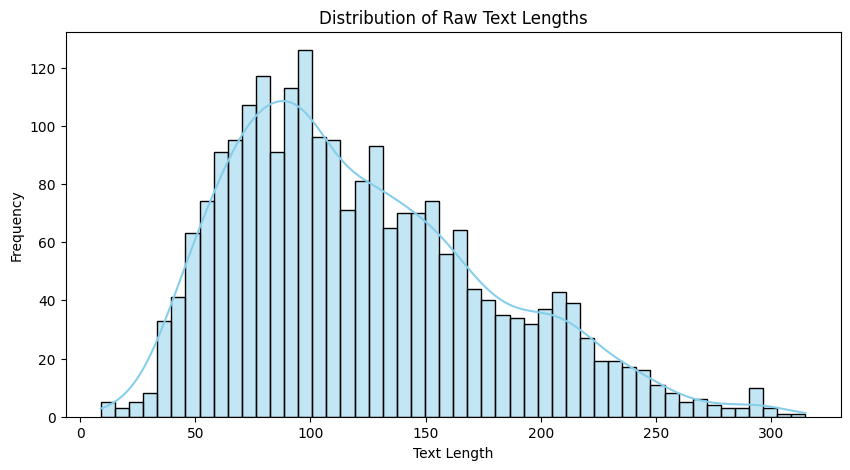

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/raw_text_length_distribution.png
Raw Text Length Statistics:
count    2264.000000
mean      121.962456
std        56.238979
min         9.000000
25%        79.000000
50%       111.000000
75%       157.000000
max       315.000000
Name: text_length_raw, dtype: float64


In [ ]:
# Distribution of Text Lengths (Raw Text)
df['text_length_raw'] = df['text'].apply(len)
fig_raw_length = plt.figure(figsize=(10, 5))
sns.histplot(df['text_length_raw'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Raw Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
save_plot(fig_raw_length, 'raw_text_length_distribution.png')

print("Raw Text Length Statistics:")
print(df['text_length_raw'].describe())

In [ ]:
df.head()

,text,label,text_length_raw
0,"According to Gran , the company has no plans t...",neutral,127
1,"For the last quarter of 2010 , Componenta 's n...",positive,193
2,"In the third quarter of 2010 , net sales incre...",positive,125
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,122
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,103


In [ ]:
df.columns

Index(['text', 'label', 'text_length_raw'], dtype='object')

In [ ]:
df.shape

(2264, 3)

## Text Cleaning

In [ ]:
# define a dictionary of common english contractions for expansion
contractions_dict = {
    "don't": "do not", "doesn't": "does not", "didn't": "does not",
    "can't": "cannot", "couldn't": "could not", "won't": "would not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "i'm": "i am", "you're": "you are", "he's": "he is",
    "she's": "she is", "it's": "it is", "we're": "we are",
    "they're": "they are", "i've": "i have", "you've": "you have",
    "we've": "we have", "they've": "they have"
}

# instantiate the lemmatizer and define english stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def expand_contractions(text):
    # expand contractions using the predefined dictionary
    for word, expanded in contractions_dict.items():
        text = re.sub(r'\b' + word + r'\b', expanded, text)
    return text

def clean_tweet(text):
    # check for missing or null values
    if not isinstance(text, str):
        return ""

    # 1. lowercase all text to ensure uniformity
    text = text.lower()

    # 2. handle contractions (e.g., "don't" -> "do not")
    text = expand_contractions(text)

    # 3. remove urls, mentions (@user), hashtags (#), numbers, and special characters
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # remove urls
    text = re.sub(r'@\w+', '', text)                                         # remove mentions
    text = re.sub(r'#\w+', '', text)                                         # remove hashtags
    text = re.sub(r'\d+', '', text)                                          # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                                      # remove punctuation/special chars

    # 4. remove stopwords and lemmatize words
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # rejoin the cleaned words into a single string
    return ' '.join(cleaned_words)

# apply the cleaning pipeline to the dataset's 'text' column
df['cleaned_text'] = df['text'].apply(clean_tweet)

# display a comparison of raw vs cleaned text
df[['text', 'cleaned_text']].head()


,text,cleaned_text
0,"According to Gran , the company has no plans t...",according gran company plan move production ru...
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled eurm ...
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increased eur mn operat...
3,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur mn eur mn correspond...
4,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn eur mn repres...


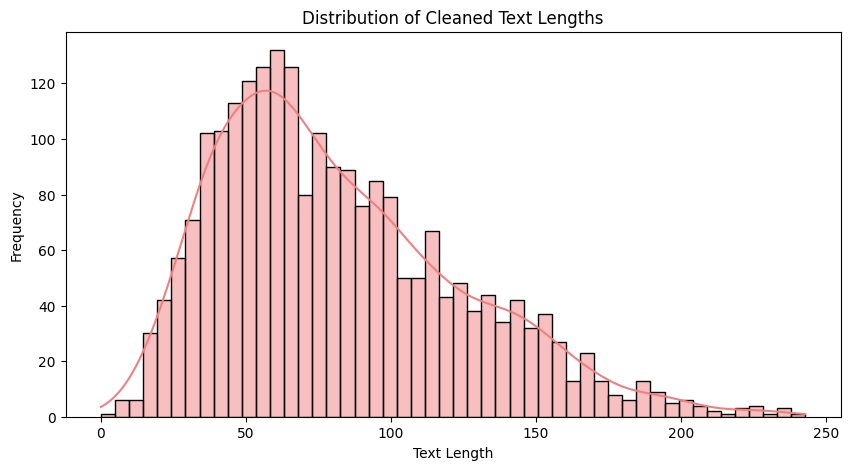

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/cleaned_text_length_distribution.png
Cleaned Text Length Statistics:
count    2264.000000
mean       82.053445
std        42.490957
min         0.000000
25%        50.000000
50%        73.000000
75%       107.000000
max       243.000000
Name: text_length_cleaned, dtype: float64


In [ ]:
# Distribution of Text Lengths (Cleaned Text)
df['text_length_cleaned'] = df['cleaned_text'].apply(len)
fig_cleaned_length = plt.figure(figsize=(10, 5))
sns.histplot(df['text_length_cleaned'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Cleaned Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
save_plot(fig_cleaned_length, 'cleaned_text_length_distribution.png')

print("Cleaned Text Length Statistics:")
print(df['text_length_cleaned'].describe())

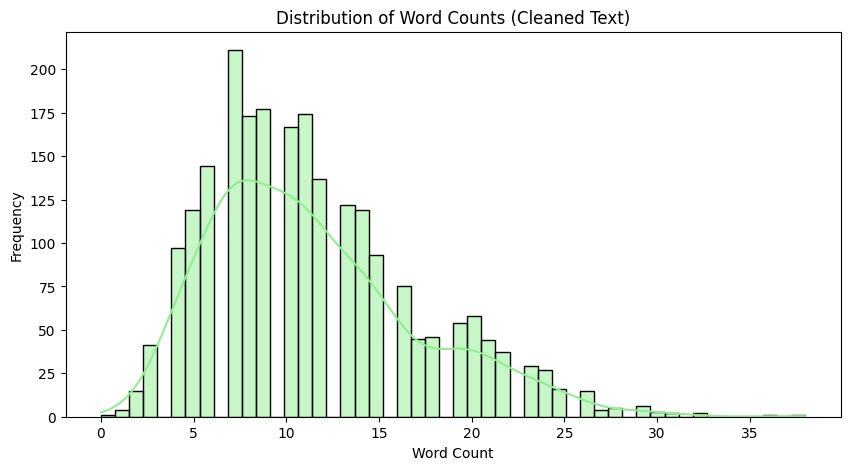

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/word_count_cleaned_distribution.png
Cleaned Text Word Count Statistics:
count    2264.000000
mean       11.425353
std         5.646118
min         0.000000
25%         7.000000
50%        10.000000
75%        14.000000
max        38.000000
Name: word_count_cleaned, dtype: float64


In [ ]:
# Distribution of Word Counts (Cleaned Text)
df['word_count_cleaned'] = df['cleaned_text'].apply(lambda x: len(x.split()))
fig_word_count = plt.figure(figsize=(10, 5))
sns.histplot(df['word_count_cleaned'], bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Word Counts (Cleaned Text)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()
save_plot(fig_word_count, 'word_count_cleaned_distribution.png')

print("Cleaned Text Word Count Statistics:")
print(df['word_count_cleaned'].describe())

## Visualization (Word Cloud & Frequencies)

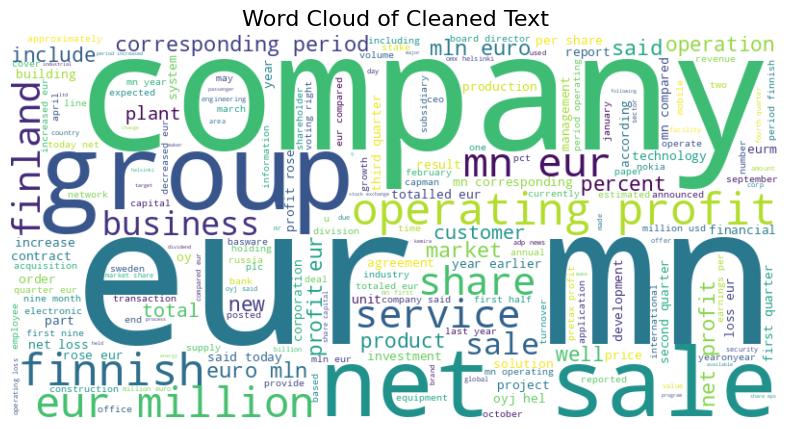

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/word_cloud_cleaned_text.png


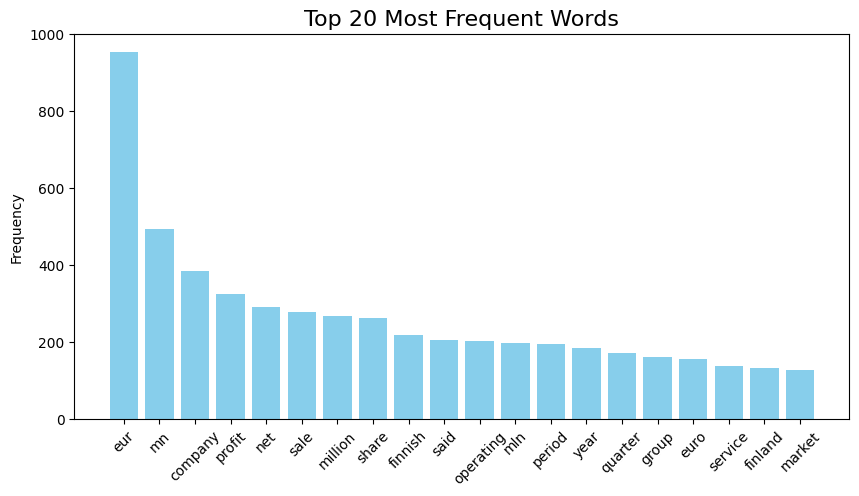

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/top_20_frequent_words.png


In [ ]:
# combine all cleaned tweets into a single large string for visualization
all_text = ' '.join(df['cleaned_text'].tolist())

# 1. generate and display a word cloud
fig_wordcloud = plt.figure(figsize=(10, 5))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text', fontsize=16)
plt.show()
save_plot(fig_wordcloud, 'word_cloud_cleaned_text.png')

# 2. display the top 20 most frequent words
word_counts = Counter(all_text.split())
most_common_words = word_counts.most_common(20)

# extract words and their frequencies for plotting
words, counts = zip(*most_common_words)

fig_freq_words = plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='skyblue')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()
save_plot(fig_freq_words, 'top_20_frequent_words.png')

## Splitting, Tokenization, and Padding

In [ ]:
# define features (x) and target labels (y)
x = df['cleaned_text'].values
y = df['label'].values

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# split dataset into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)


In [ ]:
# initialize the keras tokenizer
vocab_size = 20000  # maximum number of words to keep in the vocabulary (increased from 10000)
oov_token = "<OOV>" # out of vocabulary token

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# fit the tokenizer only on the training data to avoid data leakage
tokenizer.fit_on_texts(x_train)

# convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(x_train)
test_sequences = tokenizer.texts_to_sequences(x_test)

In [ ]:
# determine optimal sequence length using the 95th percentile rule
sequence_lengths = [len(seq) for seq in train_sequences]
optimal_length = int(np.percentile(sequence_lengths, 95))
print(f"95th percentile sequence length: {optimal_length}")

95th percentile sequence length: 23


In [ ]:
# apply padding to ensure uniform sequence lengths
padding_type = 'post'
trunc_type = 'post'

x_train_padded = pad_sequences(train_sequences, maxlen=optimal_length, padding=padding_type, truncating=trunc_type)
x_test_padded = pad_sequences(test_sequences, maxlen=optimal_length, padding=padding_type, truncating=trunc_type)
print(x_train_padded[:2])
# verify the shape of the resulting padded sequences
print(f"shape of padded training data: {x_train_padded.shape}")
print(f"shape of padded testing data: {x_test_padded.shape}")

[[2010  120   61 1360  529  292 2011   17  359    0    0    0    0    0
     0    0    0    0    0    0    0    0    0]
 [  13    5   87    2    3    2    3    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0]]
shape of padded training data: (1811, 23)
shape of padded testing data: (453, 23)


In [ ]:
word_counts = Counter(" ".join(df['cleaned_text']).split())
vocab_size = len(word_counts)
print(f" Vocab Size : {vocab_size}")

 Vocab Size : 4928


#  Three different models for text classification (Model Building and Training)

## Simple RNN with a trainable Embedding layer
The first model is a Simple Recurrent Neural Network (RNN). Simple RNNs are designed to handle sequential data by maintaining a hidden state that captures information from previous time steps. We initialize the network with an `Embedding` layer to learn dense vector representations of our vocabulary from scratch. The output layer uses a `softmax` activation function because this is a multi-class classification problem (Positive, Negative, Neutral).


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# set random seed for reproducibility
tf.random.set_seed(42)

# define model architecture
model_1 = Sequential([
    # embedding layer: learns word embeddings during training
    Embedding(input_dim=vocab_size, output_dim=300, input_length=optimal_length),

    # recurrent layer: simple rnn with 64 units
    SimpleRNN(64, return_sequences=False),

    # dense output layer: 3 classes (positive, negative, neutral)
    Dense(3, activation='softmax')
])

# compile the model
# using 'sparse_categorical_crossentropy' because labels are label-encoded integers
model_1.compile(loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [ ]:
# define early stopping callback to halt training when validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# train the model
history_1 = model_1.fit(
    x_train_padded, y_train,
    validation_data=(x_test_padded, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.6781 - loss: 0.7592 - val_accuracy: 0.7616 - val_loss: 0.5987
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8802 - loss: 0.3091 - val_accuracy: 0.7837 - val_loss: 0.5779
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9658 - loss: 0.1145 - val_accuracy: 0.8035 - val_loss: 0.5903
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9807 - loss: 0.0677 - val_accuracy: 0.7704 - val_loss: 0.6794
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.9768 - loss: 0.0750 - val_accuracy: 0.6534 - val_loss: 1.0071
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
model_1.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 23, 300)        │     1,478,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 64)             │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,505,867 (17.19 MB)

 Trainable params: 1,501,955 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,003,912 (11.46 MB)

### Model 1 Evaluation

Model 1 (Simple RNN) Test Accuracy: 78.37%
Model 1 (Simple RNN) Test Loss: 0.5779

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Classification Report (Model 1):
              precision    recall  f1-score   support

    negative       0.58      0.34      0.43        56
     neutral       0.90      0.88      0.89       276
    positive       0.62      0.78      0.69       121

    accuracy                           0.78       453
   macro avg       0.70      0.66      0.67       453
weighted avg       0.79      0.78      0.78       453

Model 1 (Simple RNN) Macro F1-score: 0.6684



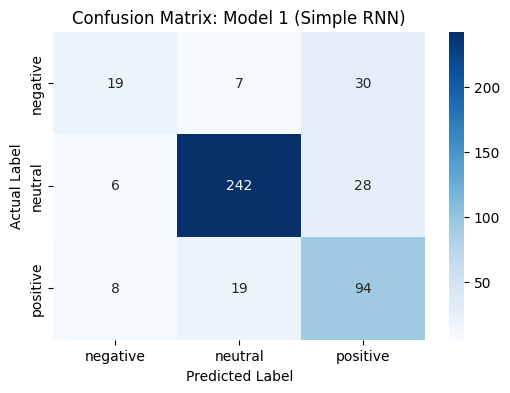

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/confusion_matrix_model_1.png


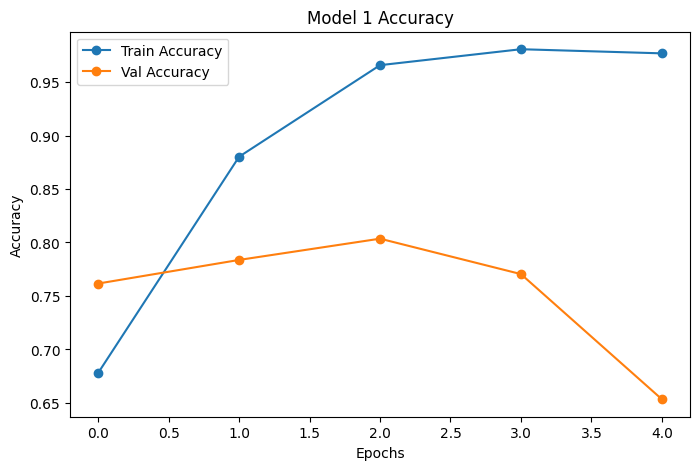

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_1_accuracy_plot.png


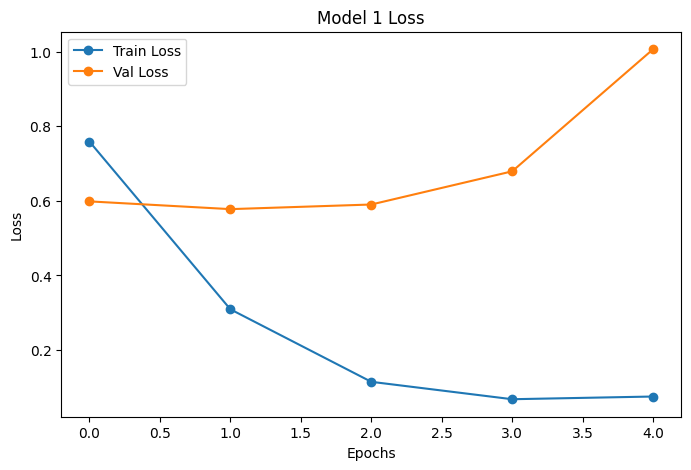

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_1_loss_plot.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# evaluate on test data
loss_1, accuracy_1 = model_1.evaluate(x_test_padded, y_test, verbose=0)
print(f"Model 1 (Simple RNN) Test Accuracy: {accuracy_1 * 100:.2f}%")
print(f"Model 1 (Simple RNN) Test Loss: {loss_1:.4f}\n")

# generate predictions
y_pred_probs_1 = model_1.predict(x_test_padded)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

# print classification report
target_names = label_encoder.inverse_transform([0, 1, 2])
report_1 = classification_report(y_test, y_pred_1, target_names=target_names, output_dict=True)
print("Classification Report (Model 1):")
print(classification_report(y_test, y_pred_1, target_names=target_names))
print(f"Model 1 (Simple RNN) Macro F1-score: {report_1['macro avg']['f1-score']:.4f}\n")

# plot confusion matrix
cm_1 = confusion_matrix(y_test, y_pred_1)
fig_cm_1 = plt.figure(figsize=(6, 4))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Model 1 (Simple RNN)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
save_plot(fig_cm_1, 'confusion_matrix_model_1.png')

# plot training vs validation accuracy
fig_accuracy_1 = plt.figure(figsize=(8, 5))
plt.plot(history_1.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model 1 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
save_plot(fig_accuracy_1, 'model_1_accuracy_plot.png')

# plot training vs validation loss
fig_loss_1 = plt.figure(figsize=(8, 5))
plt.plot(history_1.history['loss'], label='Train Loss', marker='o')
plt.plot(history_1.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model 1 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
save_plot(fig_loss_1, 'model_1_loss_plot.png')

In [ ]:
model_1_path = MODELS_PATH / 'model_1_simple_rnn.keras'
model_1.save(model_1_path)
print(f"Model 1 saved to: {model_1_path}")

Model 1 saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Models/model_1_simple_rnn.keras


## LSTM with a trainable Embedding layer


### Building and training model 2

In [ ]:
from tensorflow.keras.layers import LSTM

# set random seed for reproducibility
tf.random.set_seed(42)

# define LSTM model architecture
model_2 = Sequential([
    # trainable embedding layer
    Embedding(input_dim=vocab_size, output_dim=300, input_length=optimal_length),

    LSTM(64, return_sequences=False),

    # # dropout for regularization
    Dropout(0.3),

    # dense output layer
    Dense(3, activation='softmax')
])

# compile the model
model_2.compile(loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [ ]:
# train the model
history_2 = model_2.fit(
    x_train_padded, y_train,
    validation_data=(x_test_padded, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.6488 - loss: 0.8699 - val_accuracy: 0.7506 - val_loss: 0.6299
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7891 - loss: 0.4780 - val_accuracy: 0.7969 - val_loss: 0.5420
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.8377 - loss: 0.3432 - val_accuracy: 0.7903 - val_loss: 0.5692
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8586 - loss: 0.2873 - val_accuracy: 0.8013 - val_loss: 0.7062
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9359 - loss: 0.1743 - val_accuracy: 0.7881 - val_loss: 0.7076
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
model_2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 23, 300)        │     1,478,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,716,107 (17.99 MB)

 Trainable params: 1,572,035 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,144,072 (11.99 MB)

### Model 2 Evaluation


Model 2 (LSTM) Test Accuracy: 79.69%
Model 2 (LSTM) Test Loss: 0.5420

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Classification Report (Model 2):
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        56
     neutral       0.92      0.92      0.92       276
    positive       0.60      0.88      0.71       121

    accuracy                           0.80       453
   macro avg       0.51      0.60      0.55       453
weighted avg       0.72      0.80      0.75       453

Model 2 (LSTM) Macro F1-score: 0.5451



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

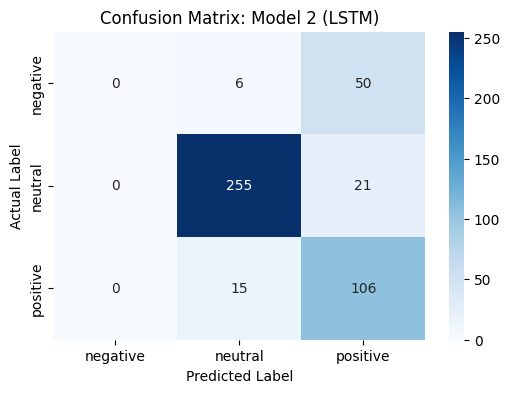

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/confusion_matrix_model_2.png


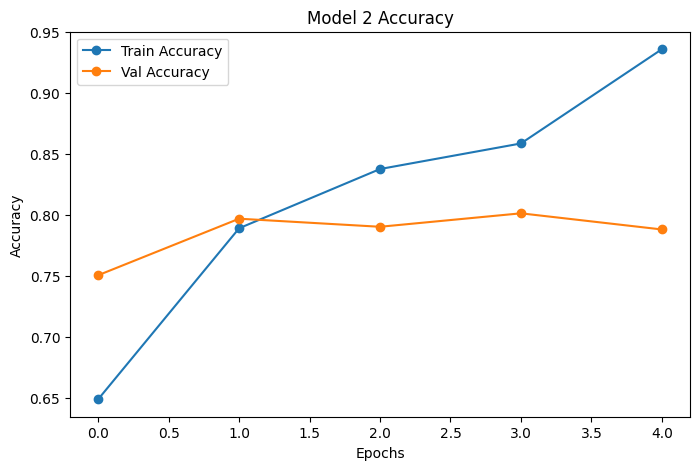

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_2_accuracy_plot.png


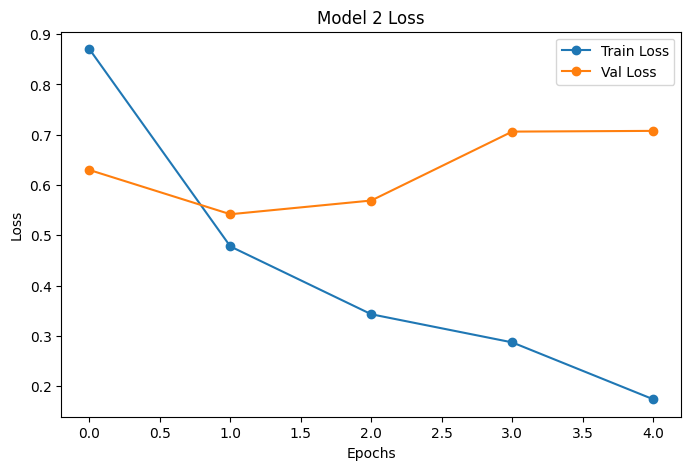

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_2_loss_plot.png


In [ ]:
# evaluate on test data
loss_2, accuracy_2 = model_2.evaluate(x_test_padded, y_test, verbose=0)
print(f"Model 2 (LSTM) Test Accuracy: {accuracy_2 * 100:.2f}%")
print(f"Model 2 (LSTM) Test Loss: {loss_2:.4f}\n")

# generate predictions
y_pred_probs_2 = model_2.predict(x_test_padded)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

# print classification report
report_2 = classification_report(y_test, y_pred_2, target_names=target_names, output_dict=True)
print("Classification Report (Model 2):")
print(classification_report(y_test, y_pred_2, target_names=target_names))
print(f"Model 2 (LSTM) Macro F1-score: {report_2['macro avg']['f1-score']:.4f}\n")

# plot confusion matrix
cm_2 = confusion_matrix(y_test, y_pred_2)
fig_cm_2 = plt.figure(figsize=(6, 4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Model 2 (LSTM)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
save_plot(fig_cm_2, 'confusion_matrix_model_2.png')

# plot training vs validation accuracy
fig_accuracy_2 = plt.figure(figsize=(8, 5))
plt.plot(history_2.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model 2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
save_plot(fig_accuracy_2, 'model_2_accuracy_plot.png')

# plot training vs validation loss
fig_loss_2 = plt.figure(figsize=(8, 5))
plt.plot(history_2.history['loss'], label='Train Loss', marker='o')
plt.plot(history_2.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model 2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
save_plot(fig_loss_2, 'model_2_loss_plot.png')

In [ ]:
model_2_path = MODELS_PATH / 'model_2_lstm.keras'
model_2.save(model_2_path)
print(f"Model 2 saved to: {model_2_path}")

Model 2 saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Models/model_2_lstm.keras


## LSTM with pretrained Word2Vec embeddings


In [ ]:
import gensim.downloader as api
import numpy as np

embedding_model = api.load('word2vec-google-news-300')

embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Build the embedding matrix
for word, i in tokenizer.word_index.items():
    if i < vocab_size: # Only keep top words up to vocab_size
        if word in embedding_model:
            embedding_vector = embedding_model[word]
            embedding_matrix[i] = embedding_vector
        else:
            # Words not found in embedding index will be all-zeros
            pass

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
word2vec_model_path = MODELS_PATH / 'word2vec-google-news-300.bin'
embedding_model.save_word2vec_format(str(word2vec_model_path), binary=True)
print(f"Pre-trained Word2Vec model saved to: {word2vec_model_path}")

Pre-trained Word2Vec model saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Models/word2vec-google-news-300.bin


### Building and Training Model 3

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Build the LSTM Model with Pre-trained Embedding Layer
model_3 = Sequential()
model_3.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=optimal_length,
    trainable=False # Freezing the pre-trained embeddings
))
model_3.add(LSTM(64, return_sequences=False))
model_3.add(Dropout(0.3))
model_3.add(Dense(3, activation='softmax')) # 3 classes for positive/negative/neutral


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# compile the model
model_3.compile(loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [ ]:
# train the model
history_3 = model_3.fit(
    x_train_padded, y_train,
    validation_data=(x_test_padded, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.6742 - loss: 0.7802 - val_accuracy: 0.7616 - val_loss: 0.6059
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.7631 - loss: 0.5262 - val_accuracy: 0.7903 - val_loss: 0.5031
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7946 - loss: 0.4493 - val_accuracy: 0.8079 - val_loss: 0.4602
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8255 - loss: 0.3863 - val_accuracy: 0.7881 - val_loss: 0.5299
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8343 - loss: 0.3745 - val_accuracy: 0.8102 - val_loss: 0.4206
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8642 - loss: 0.3290 - val_accuracy: 0.8278 - val_loss: 0.4008
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.8934 - loss: 0.2587 - val_accuracy: 0.8698 - val_loss: 0.3174
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9172 - loss: 0.2125 - val_accuracy: 0.8720 - v

In [ ]:
model_3.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 23, 300)        │     1,478,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,759,307 (6.71 MB)

 Trainable params: 93,635 (365.76 KB)

 Non-trainable params: 1,478,400 (5.64 MB)

 Optimizer params: 187,272 (731.54 KB)

### Model 3 Evaluation

Model 3 (Word2Vec LSTM) Test Accuracy: 86.98%

Model 3 (Word2Vec LSTM) Test Loss: 0.3174

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Classification Report (Model 3):
              precision    recall  f1-score   support

    negative       0.67      0.64      0.65        56
     neutral       0.94      0.96      0.95       276
    positive       0.79      0.77      0.78       121

    accuracy                           0.87       453
   macro avg       0.80      0.79      0.79       453
weighted avg       0.87      0.87      0.87       453

Model 3 (Word2Vec LSTM) Macro F1-score: 0.7948



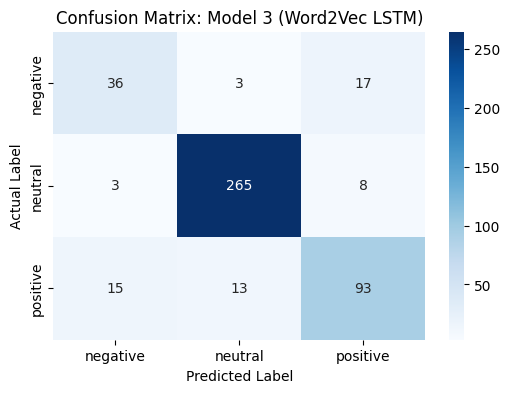

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/confusion_matrix_model_3.png


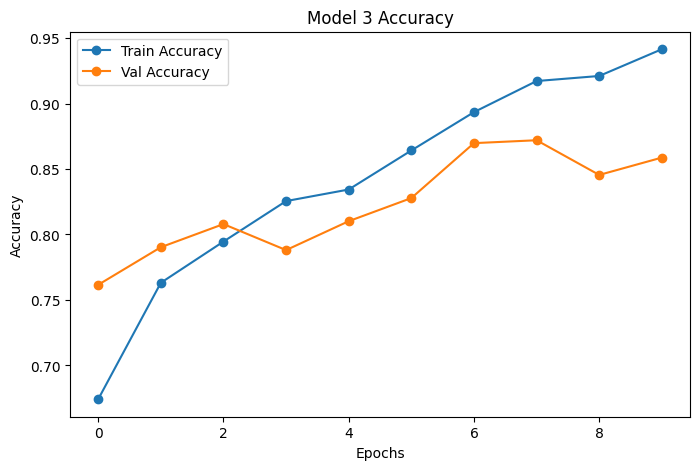

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_3_accuracy_plot.png


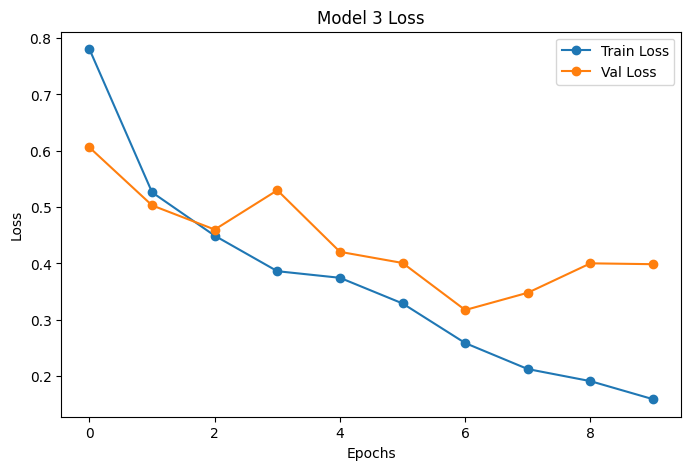

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/model_3_loss_plot.png


In [ ]:
# evaluate on test data
loss_3, accuracy_3 = model_3.evaluate(x_test_padded, y_test, verbose=0)
print(f"Model 3 (Word2Vec LSTM) Test Accuracy: {accuracy_3 * 100:.2f}%\n")
print(f"Model 3 (Word2Vec LSTM) Test Loss: {loss_3:.4f}\n")

# generate predictions
y_pred_probs_3 = model_3.predict(x_test_padded)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

# print classification report
report_3 = classification_report(y_test, y_pred_3, target_names=target_names, output_dict=True)
print("Classification Report (Model 3):")
print(classification_report(y_test, y_pred_3, target_names=target_names))
print(f"Model 3 (Word2Vec LSTM) Macro F1-score: {report_3['macro avg']['f1-score']:.4f}\n")

# plot confusion matrix
cm_3 = confusion_matrix(y_test, y_pred_3)
fig_cm_3 = plt.figure(figsize=(6, 4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Model 3 (Word2Vec LSTM)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
save_plot(fig_cm_3, 'confusion_matrix_model_3.png')

# plot training vs validation accuracy
fig_accuracy_3 = plt.figure(figsize=(8, 5))
plt.plot(history_3.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model 3 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
save_plot(fig_accuracy_3, 'model_3_accuracy_plot.png')

# plot training vs validation loss
fig_loss_3 = plt.figure(figsize=(8, 5))
plt.plot(history_3.history['loss'], label='Train Loss', marker='o')
plt.plot(history_3.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model 3 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
save_plot(fig_loss_3, 'model_3_loss_plot.png')

In [ ]:
model_3_path = MODELS_PATH / 'model_3_word2vec_lstm.keras'
model_3.save(model_3_path)
print(f"Model 3 saved to: {model_3_path}")

Model 3 saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Models/model_3_word2vec_lstm.keras


## Model Evaluation

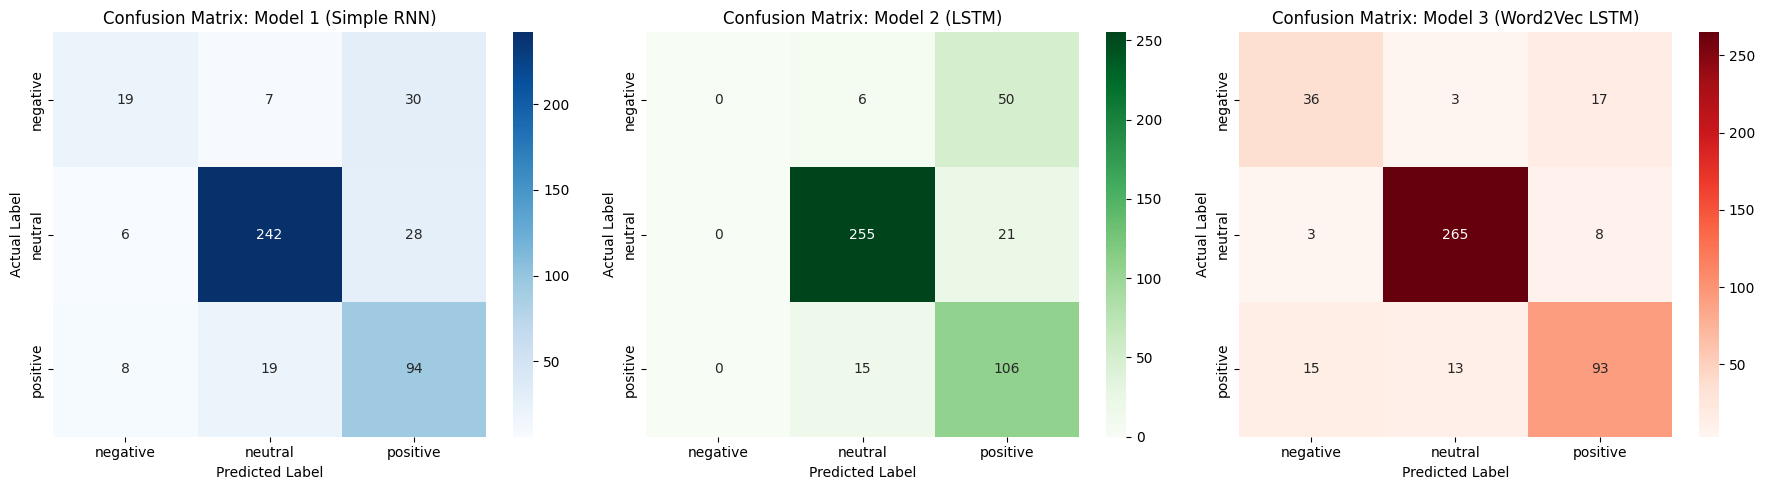

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/consolidated_confusion_matrices.png


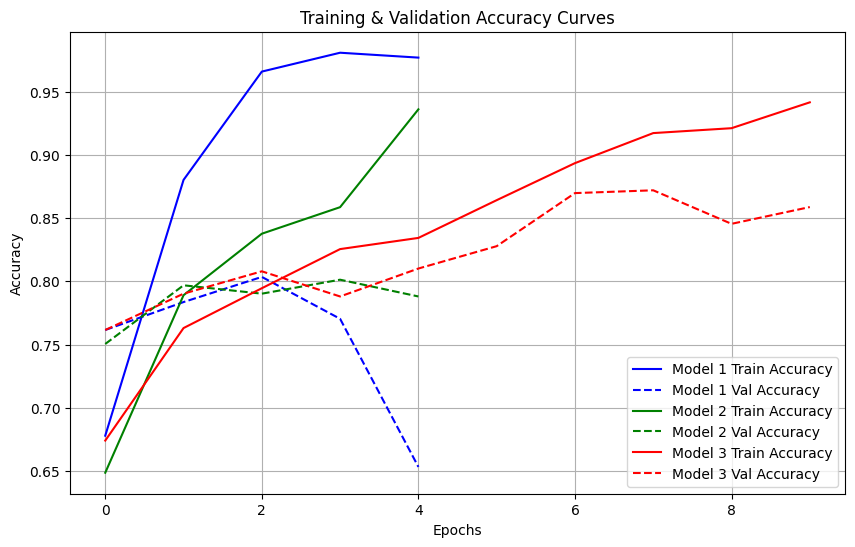

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/consolidated_accuracy_curves.png


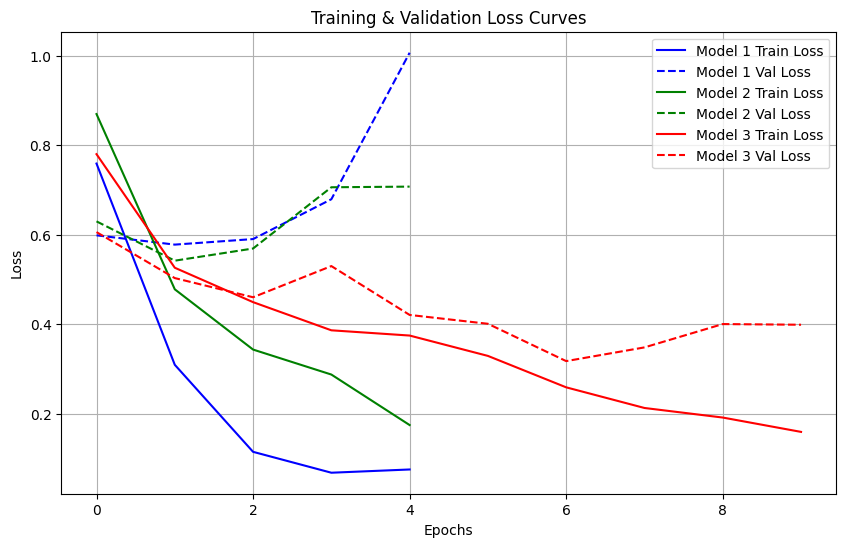

Plot saved to: /content/drive/MyDrive/3. 6CS012: AI & ML Part III/Figures/consolidated_loss_curves.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig_all_cm, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 1 Confusion Matrix
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix: Model 1 (Simple RNN)')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Model 2 Confusion Matrix
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix: Model 2 (LSTM)')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

# Model 3 Confusion Matrix
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names, ax=axes[2])
axes[2].set_title('Confusion Matrix: Model 3 (Word2Vec LSTM)')
axes[2].set_ylabel('Actual Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
save_plot(fig_all_cm, 'consolidated_confusion_matrices.png')


fig_all_accuracy = plt.figure(figsize=(10, 6))
plt.plot(history_1.history['accuracy'], label='Model 1 Train Accuracy', color='blue', linestyle='-')
plt.plot(history_1.history['val_accuracy'], label='Model 1 Val Accuracy', color='blue', linestyle='--')

plt.plot(history_2.history['accuracy'], label='Model 2 Train Accuracy', color='green', linestyle='-')
plt.plot(history_2.history['val_accuracy'], label='Model 2 Val Accuracy', color='green', linestyle='--')

plt.plot(history_3.history['accuracy'], label='Model 3 Train Accuracy', color='red', linestyle='-')
plt.plot(history_3.history['val_accuracy'], label='Model 3 Val Accuracy', color='red', linestyle='--')

plt.title('Training & Validation Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
save_plot(fig_all_accuracy, 'consolidated_accuracy_curves.png')


fig_all_loss = plt.figure(figsize=(10, 6))
plt.plot(history_1.history['loss'], label='Model 1 Train Loss', color='blue', linestyle='-')
plt.plot(history_1.history['val_loss'], label='Model 1 Val Loss', color='blue', linestyle='--')

plt.plot(history_2.history['loss'], label='Model 2 Train Loss', color='green', linestyle='-')
plt.plot(history_2.history['val_loss'], label='Model 2 Val Loss', color='green', linestyle='--')

plt.plot(history_3.history['loss'], label='Model 3 Train Loss', color='red', linestyle='-')
plt.plot(history_3.history['val_loss'], label='Model 3 Val Loss', color='red', linestyle='--')

plt.title('Training & Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
save_plot(fig_all_loss, 'consolidated_loss_curves.png')


# GUI for Real Time Prediction (Gradio)

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the prediction function
def predict_sentiment(text):
    # Clean the raw input text using our established pipeline
    cleaned_text = clean_tweet(text)

    # Tokenize and pad the sequence
    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded_seq = pad_sequences(seq, maxlen=optimal_length, padding='post')

    prediction_probs = model_3.predict(padded_seq, verbose=0)[0]

    # Map probabilities back to original label names ('positive', 'negative', 'neutral')
    labels = label_encoder.inverse_transform([0, 1, 2])

    # Return a dictionary of probabilities for Gradio to display as a confidence bar chart
    return {labels[i]: float(prediction_probs[i]) for i in range(len(labels))}

# Define the Gradio Interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=4, placeholder="Type a financial phrase or tweet here. (e.g., 'Operating profit rose to EUR 13.1 mn from EUR 8.7 mn')", label="Input Financial Text"),
    outputs=gr.Label(num_top_classes=3, label="Predicted Sentiment Confidence"),
    title="Real-Time Financial Sentiment Classifier",
    theme=gr.themes.Monochrome()
)

interface.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://754990dc7b450d9c0a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
